In [2]:
import subprocess
subprocess.run(["pip","install","xgboost","scikit-learn","seaborn","matplotlib","pandas","numpy"])

CompletedProcess(args=['pip', 'install', 'xgboost', 'scikit-learn', 'seaborn', 'matplotlib', 'pandas', 'numpy'], returncode=0)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries loaded!")

Matplotlib is building the font cache; this may take a moment.


All libraries loaded!


In [4]:
df = pd.read_csv("train.csv")
print(df.shape)
print(df.head())

(1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008  

In [5]:
df["LotFrontage"].fillna(df["LotFrontage"].median(), inplace=True)
df.fillna(0, inplace=True)
df = pd.get_dummies(df)
df.fillna(0, inplace=True)
print("✅ Cleaning done! Shape:", df.shape)

✅ Cleaning done! Shape: (1460, 305)


C:\Users\katta\AppData\Local\Temp\ipykernel_58852\3596813590.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["LotFrontage"].fillna(df["LotFrontage"].median(), inplace=True)


In [6]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
error = mean_absolute_error(y_test, predictions)
print(f"✅ Model trained!")
print(f"Average prediction error: ${error:,.0f}")

✅ Model trained!
Average prediction error: $15,975


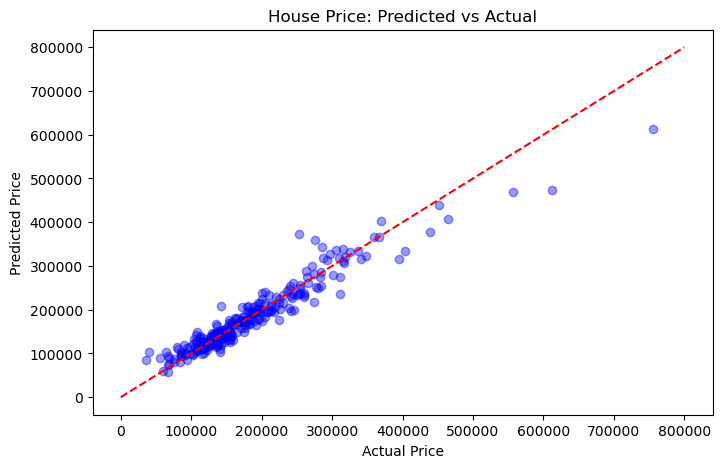

🎉 House Price Project Complete!


In [7]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, predictions, alpha=0.4, color="blue")
plt.plot([0, 800000], [0, 800000], "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("House Price: Predicted vs Actual")
plt.savefig("house_price_result.png")
plt.show()
print("🎉 House Price Project Complete!")